In [1]:
# Telco Customer Churn Data Preparation

## 1. Import Libraries
## 2. Load Dataset
## 3. Basic Data Review
## 4. Train-Test Split
## 5. EDA on Training Data Only
## 6. Handle Missing Values
## 7. Encode Categorical Variables
## 8. Scale Numerical Variables
## 9. Check Class Balance
## 10. Save Cleaned Dataset
## 11. Summary of Changes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4930, 20)
Testing data shape: (2113, 20)


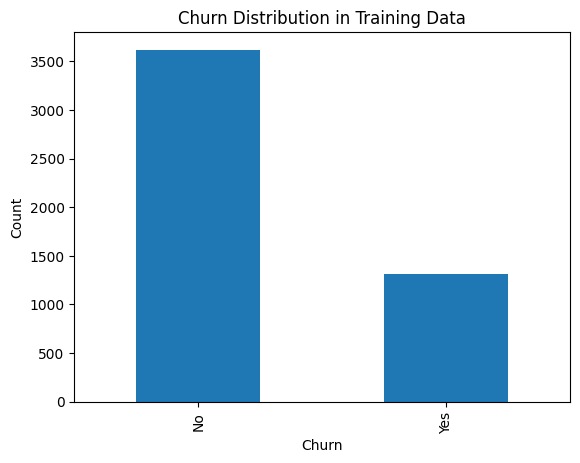

In [13]:
y_train.value_counts().plot(kind="bar")
plt.title("Churn Distribution in Training Data")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

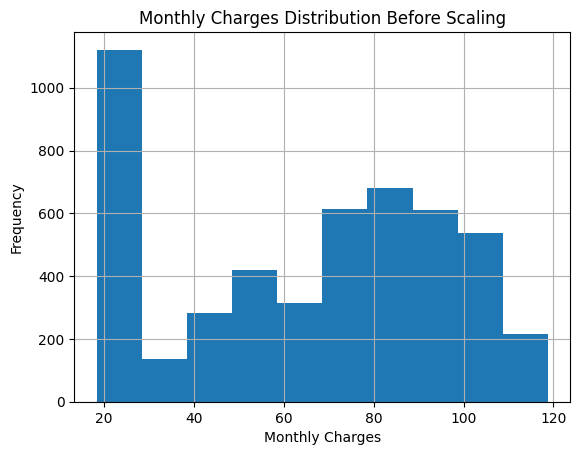

In [14]:
X_train["MonthlyCharges"].hist()
plt.title("Monthly Charges Distribution Before Scaling")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

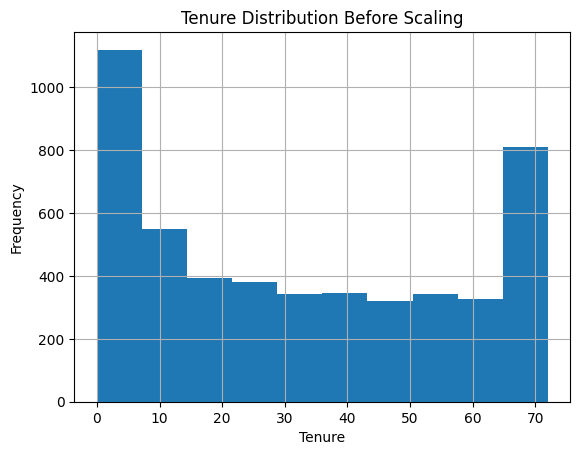

In [15]:
X_train["tenure"].hist()
plt.title("Tenure Distribution Before Scaling")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

In [16]:
print(X_train.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        7
dtype: int64


In [17]:
median_total_charges = X_train["TotalCharges"].median()

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(median_total_charges)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(median_total_charges)

In [18]:
X_train = X_train.drop("customerID", axis=1)
X_test = X_test.drop("customerID", axis=1)

In [19]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [20]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

X_train_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,0,5,80.20,384.25,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2270,1,3,86.85,220.95,False,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
6930,0,3,75.15,216.75,False,True,False,True,False,True,...,False,False,False,False,False,False,True,True,False,False
2257,0,60,80.55,4847.05,False,False,False,True,False,True,...,False,True,False,True,True,False,False,True,False,False
898,0,12,98.90,1120.95,False,False,False,True,False,False,...,False,True,False,True,False,False,True,False,False,False


In [21]:
scaler = StandardScaler()

X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])

In [22]:
y_train_encoded = y_train.map({"No": 0, "Yes": 1})
y_test_encoded = y_test.map({"No": 0, "Yes": 1})

In [23]:
X_train_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,-0.438147,-1.114728,0.504286,-0.837871,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2270,2.282338,-1.195884,0.724189,-0.909151,False,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
6930,-0.438147,-1.195884,0.337292,-0.910985,False,True,False,True,False,True,...,False,False,False,False,False,False,True,True,False,False
2257,-0.438147,1.117066,0.515860,1.110142,False,False,False,True,False,True,...,False,True,False,True,True,False,False,True,False,False
898,-0.438147,-0.830682,1.122660,-0.516301,False,False,False,True,False,False,...,False,True,False,True,False,False,True,False,False,False


In [24]:
print("Final training shape:", X_train_encoded.shape)
print("Final testing shape:", X_test_encoded.shape)

Final training shape: (4930, 30)
Final testing shape: (2113, 30)


In [25]:
train_cleaned = X_train_encoded.copy()
train_cleaned["Churn"] = y_train_encoded

test_cleaned = X_test_encoded.copy()
test_cleaned["Churn"] = y_test_encoded

train_cleaned.to_csv("telco_churn_train_cleaned.csv", index=False)
test_cleaned.to_csv("telco_churn_test_cleaned.csv", index=False)